# Annealed power-law graph → GLV dynamics: volatility–size scaling vs tail exponent

Degree-based, Chung–Lu-normalized annealed adjacency fed into the rescaled GLV
system, held at the critical interaction mean **$\mu=0$** throughout. We sweep
the power-law tail exponent $\alpha$ and ask how the **volatility–size scaling
slope $\beta$** responds.

**Why $\mu=0$.** Both empirically (the located $\mu_c$ collapses toward $0$ on
these sparse, hub-dominated graphs) and theoretically, criticality sits at
$\mu_c=0$ here. So rather than locating $\mu_c$ per realization, we fix $\mu=0$ —
the system's marginal point — and vary only the graph's tail.

**Construction (one realization).** Continuous hidden degrees — no rounding, no
configuration-model graph; the annealed matrix is built directly.

$$k_i = k_{\min}\,U_i^{-1/\alpha},\quad U_i\sim\mathrm{Unif}(0,1)
\qquad\bigl(P(k)\propto k^{-(1+\alpha)},\ k\ge k_{\min}\bigr)$$

$$C=\bar k=\tfrac1N\textstyle\sum_i k_i,
\qquad p_{ij}=\frac{k_ik_j}{k_ik_j+NC}\ \ (i\ne j)$$

Chung–Lu normalization ($NC=\sum_l k_l$), so $k_i$ is the expected degree. The
annealed adjacency matches a $\mathrm{Bernoulli}(p_{ij})$ in mean and variance,
symmetric, **diagonal zeroed (no self-loops)**:

$$A_{ij}=p_{ij}+\sqrt{p_{ij}(1-p_{ij})}\,B_{ij}\ \ (i\ne j),
\qquad A_{ii}=0,\qquad B_{ij}=B_{ji}\sim\mathcal N(0,1).$$

Interaction matrix at $\mu=0$ (pure disorder, no mean-field shift):

$$\alpha_{ij}=\frac{\mu}{C}+\frac{\sigma}{\sqrt C}\,B^{(\alpha)}_{ij}
\;\xrightarrow{\ \mu=0\ }\;\frac{\sigma}{\sqrt C}\,B^{(\alpha)}_{ij},
\qquad W_{ij}=A_{ij}\,\alpha_{ij}.$$

The diagonal is zero throughout ($W_{ii}=0$): each node's self-regulation is the
bare logistic term $-y_i$ in the rescaled RHS — no matrix self-coupling.

**Observable.** For each $\alpha$ we pool several realizations, resample
abundances on a yearly grid, and fit per-species volatility $\sigma_i$ against
mean size $\langle S_i\rangle$ as a power law $\sigma_i\propto\langle
S_i\rangle^{\beta}$. The end product is $\beta(\alpha)$, fit with a **linear** and
a **quadratic** model.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import glv

glv.apply_style()

# --- fixed parameters (all adjustable) -------------------------------------
N         = 4_000    # nodes (memory ~ n_runs * N^2 for the dense W batch)
k_min     = 1.0      # degree lower cutoff
sigma     = 0.15     # interaction disorder, held fixed near the graph's sigma_c
mu        = 0.0      # interaction mean: FIXED at 0 (mu_c = 0 here, empirically & theoretically)

# --- alpha sweep -----------------------------------------------------------
# power-law tail exponent: P(k) ~ k^-(1+alpha), tau = 1+alpha.
# small alpha -> heavy tail (dominant hubs); large alpha -> light tail (homogeneous).
alpha_grid = np.linspace(0.6, 3.0, 10)   # the swept exponents
alpha_demo = 1.5                          # single-realization example below

# --- integration / observables ---------------------------------------------
tau_max   = 1e4      # rescaled-time horizon per run
n_years   = 100      # yearly resample grid
n_runs    = 20       # pooled realizations per alpha
n_bins    = 25       # equal-count bins for the volatility-vs-size fit

seed = 0
rng = np.random.default_rng(seed)

ACCENT = "#c2571a"  # burnt orange

**Operating point — $\sigma$ fixed, $\mu=0$.** A power-law graph destabilizes the
GLV cooperatively through its *hubs*: the interaction spectral radius scales like
$\sigma\sqrt{k_{\max}/C}$, so the critical disorder is
$\sigma_c\sim\sqrt{C/k_{\max}}\approx0.15$ for these parameters. We hold
$\sigma=0.15$ (richest near-critical hub volatility) and fix the interaction mean
at $\mu=0$ — the critical/marginal point for these graphs, where no mean-field
cooperative drift or antagonism is added on top of the disorder. With $\mu=0$ the
per-realization $\mu_c$-search is unnecessary; the only control parameter left is
the graph's **tail exponent $\alpha$**, which we sweep.

## 1 · Construction

Build $k$, $p_{ij}$, and the annealed adjacency $A$. Summary statistics only — the
top pair saturates softly at $p<1$, and the realized mean degree $\langle\sum_j p_{ij}\rangle$
tracks $C=\bar k$ (Chung–Lu self-consistency).

In [2]:
def sym_noise(N, rng):
    '''Symmetric matrix with every entry ~ N(0,1), diagonal included.

    (G+G^T)/sqrt(2) leaves the diagonal at variance 2, so it is overwritten with
    independent unit normals to keep Var[A_ii] = p_ii(1-p_ii) exact.
    '''
    G = rng.standard_normal((N, N))
    B = (G + G.T) / np.sqrt(2.0)
    B[np.diag_indices(N)] = rng.standard_normal(N)
    return B


def build_power_graph(N, alpha, k_min, rng):
    '''Sample power-law hidden degrees and build the annealed adjacency A.

    Returns k (degrees), P (connection probabilities), A (annealed adjacency),
    C = <k> (mean-degree constant). Diagonal zeroed (no self-loops).
    '''
    U = rng.uniform(0.0, 1.0, size=N)
    k = k_min * U ** (-1.0 / alpha)
    C = float(k.mean())
    outer = np.outer(k, k)
    P = outer / (outer + N * C)                      # Chung-Lu: NC = sum_l k_l
    A = P + np.sqrt(P * (1.0 - P)) * sym_noise(N, rng)
    A[np.diag_indices(N)] = 0.0                       # no self-loops
    return k, P, A, C


def build_W(A, C, mu, sigma, B):
    '''Annealed interaction matrix W = A * (mu/C + sigma/sqrt(C) B).

    A has a zero diagonal, so W_ii = 0 (no matrix self-coupling). At the fixed
    mu = 0 used throughout this notebook the mean-field term drops and
    W = A * (sigma/sqrt(C)) B; mu is kept as an argument so the construction
    stays explicit. Pass a frozen disorder draw B = sym_noise(N, rng).
    '''
    return A * ((mu / C) + (sigma / np.sqrt(C)) * B)


def loglog_binfit(s, v, n_bins):
    '''Equal-count log bins of v(s) plus a power-law (log-log) fit.'''
    order = np.argsort(s)
    s_sorted, v_sorted = s[order], v[order]
    splits = np.array_split(np.arange(s_sorted.size), n_bins)
    bin_s = np.array([s_sorted[idx].mean() for idx in splits])
    bin_v = np.array([v_sorted[idx].mean() for idx in splits])
    bin_sem = np.array([v_sorted[idx].std(ddof=1) / np.sqrt(idx.size) for idx in splits])
    slope, intercept = np.polyfit(np.log10(bin_s), np.log10(bin_v), 1)
    return bin_s, bin_v, bin_sem, slope, intercept, splits[0].size


# Example graph at alpha_demo (summary stats only).
k, P, A, C = build_power_graph(N, alpha_demo, k_min, rng)

mean_deg = float(P.sum(axis=1).mean())
print(f"example graph at alpha_demo = {alpha_demo}  (tail exponent tau = {1 + alpha_demo})")
print(f"N = {N}")
print(f"k:  min={k.min():.2f}  median={np.median(k):.2f}  max={k.max():.1f}")
print(f"C = <k> = {C:.3f}")
print(f"p_ij in ({P.min():.2e}, {P.max():.4f})   symmetric = {np.allclose(P, P.T)}")
print(f"realized mean degree <sum_j p_ij> = {mean_deg:.3f}   (ratio to C: {mean_deg / C:.3f})")
print(f"A: mean={A.mean():.4f}  std={A.std():.4f}  symmetric = {np.allclose(A, A.T)}  zero-diag = {np.allclose(np.diag(A), 0.0)}")

example graph at alpha_demo = 1.5  (tail exponent tau = 2.5)
N = 4000
k:  min=1.00  median=1.60  max=302.6
C = <k> = 3.067
p_ij in (8.16e-05, 0.8818)   symmetric = True
realized mean degree <sum_j p_ij> = 2.934   (ratio to C: 0.957)
A: mean=0.0007  std=0.0270  symmetric = True  zero-diag = True


## 2 · One realization at $\mu=0$ — the volatility–size slope $\beta$

Before the sweep, the per-$\alpha$ measurement in isolation. `beta_for_alpha`
pools `n_runs` realizations at $\mu=0$ (fresh $k$, $A$, disorder $B$, and initial
condition each run) via `glv.sweep_observables`, resamples abundances onto a
yearly grid, and fits per-species volatility $\sigma_i$ against mean size
$\langle S_i\rangle$ on equal-count log bins. The slope is $\beta$; its standard
error comes from the log-log fit covariance. Below: one call at `alpha_demo`,
with the volatility–size cloud, binned fit, and pooled growth-rate distribution.

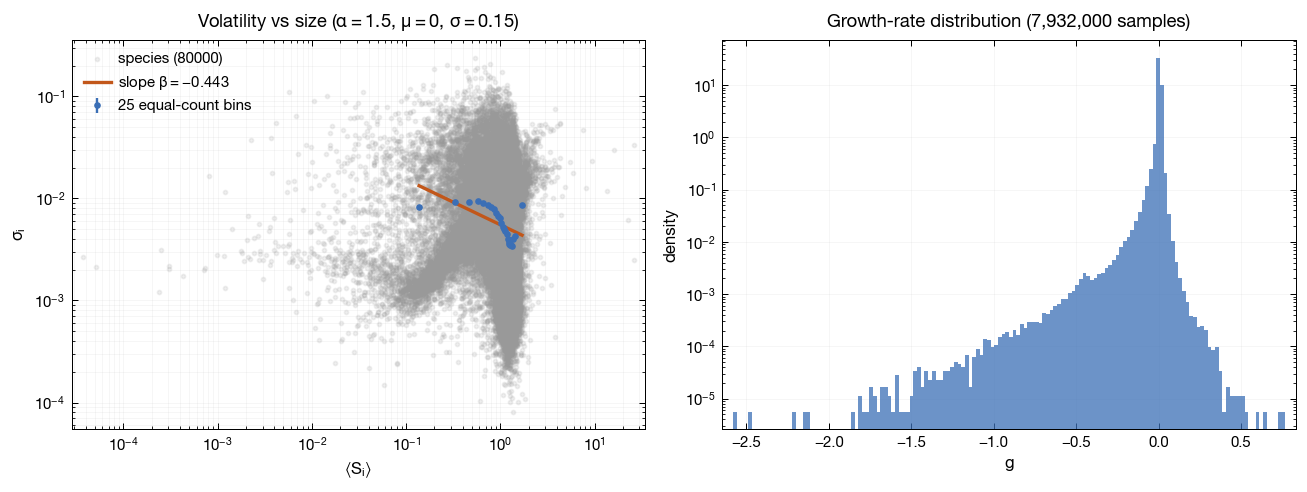

alpha_demo = 1.5:  beta = -0.4433 +- 0.1107  (20/20 runs ok)


In [3]:
def beta_for_alpha(alpha, n_runs, seed_base):
    '''Pool n_runs realizations at mu=0 for one alpha; fit the volatility-vs-size slope beta.

    Each run gets a fresh power-law graph, a frozen interaction disorder draw B,
    and an initial condition. W = build_W(A, C, mu=0, sigma, B) is integrated in
    rescaled time via glv.sweep_observables; the pooled (avg_size, volatility)
    cloud is binned in equal-count log bins and fit by a power law. Returns the
    slope beta, its standard error (from the log-log polyfit covariance), and the
    pooled arrays for plotting.
    '''
    Ws, initial_states = [], []
    for j in range(n_runs):
        rng_j = np.random.default_rng(seed_base + j)
        _, _, A_j, C_j = build_power_graph(N, alpha, k_min, rng_j)
        B_j = sym_noise(N, rng_j)                          # frozen disorder for this run
        Ws.append(build_W(A_j, C_j, mu, sigma, B_j))       # mu = 0
        x0_j = rng_j.uniform(0.0, 1.0, size=N)
        M0_j = float(x0_j.sum())
        initial_states.append(np.concatenate([x0_j / M0_j, [M0_j], [0.0]]))

    results = glv.sweep_observables(
        Ws=Ws, initial_states=initial_states, N=N, tau_max=tau_max,
        n_years=n_years, method="LSODA", max_step=1, n_workers=2,
    )
    ok = [r for r in results if r is not None]
    s_all = np.concatenate([r["avg_size"] for r in ok])
    v_all = np.concatenate([r["volatility"] for r in ok])
    g_all = np.concatenate([r["g_flat"] for r in ok])

    m = (s_all > 0) & (v_all > 0) & np.isfinite(s_all) & np.isfinite(v_all)
    s, v = s_all[m], v_all[m]
    bin_s, bin_v, bin_sem, slope, intercept, pts = loglog_binfit(s, v, n_bins)
    _, cov = np.polyfit(np.log10(bin_s), np.log10(bin_v), 1, cov=True)
    beta_sem = float(np.sqrt(cov[0, 0]))

    return {
        "alpha": alpha, "beta": slope, "beta_sem": beta_sem, "intercept": intercept,
        "n_ok": len(ok), "pts_per_bin": pts,
        "bin_s": bin_s, "bin_v": bin_v, "bin_sem": bin_sem,
        "s": s, "v": v, "g": g_all,
    }


# One example call at alpha_demo.
demo = beta_for_alpha(alpha_demo, n_runs, seed_base=0)
fit_x = np.logspace(np.log10(demo["bin_s"].min()), np.log10(demo["bin_s"].max()), 200)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.scatter(demo["s"], demo["v"], s=6, alpha=0.15, color="0.6",
           label=rf"species ({demo['s'].size})")
ax.errorbar(demo["bin_s"], demo["bin_v"], yerr=demo["bin_sem"], fmt="o", color="#3b6fb6",
            zorder=3, label=rf"{n_bins} equal-count bins")
ax.plot(fit_x, 10 ** demo["intercept"] * fit_x ** demo["beta"], color=ACCENT, lw=2,
        label=rf"slope $\beta = {demo['beta']:.3f}$")
ax.set(xscale="log", yscale="log", xlabel=r"$\langle S_i\rangle$", ylabel=r"$\sigma_i$",
       title=rf"Volatility vs size ($\alpha={alpha_demo}$, $\mu=0$, $\sigma={sigma}$)")
ax.grid(alpha=0.25, which="both")
ax.legend()

ax = axes[1]
g_fin = demo["g"][np.isfinite(demo["g"])]
ax.hist(g_fin, bins=150, density=True, color="#3b6fb6", alpha=0.75)
ax.set(xlabel=r"$g$", ylabel="density",
       title=rf"Growth-rate distribution ({g_fin.size:,} samples)", yscale="log")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()
print(f"alpha_demo = {alpha_demo}:  beta = {demo['beta']:.4f} +- {demo['beta_sem']:.4f}  "
      f"({demo['n_ok']}/{n_runs} runs ok)")

## 3 · Sweeping the tail exponent $\alpha$

Run `beta_for_alpha` across `alpha_grid`, holding $\mu=0$, $\sigma$, and $N$
fixed. Small $\alpha$ ⇒ heavy degree tail (dominant hubs); large $\alpha$ ⇒ light
tail approaching a homogeneous graph. Each grid point pools `n_runs` realizations
and returns the volatility–size slope $\beta(\alpha)$ with a standard error.

*Cost note.* This integrates `len(alpha_grid) × n_runs` systems of $N$ ODEs; peak
memory scales as `n_runs · N²` (dense $W$ held per batch). Trim `N`, `n_runs`, or
the grid if needed.

In [4]:
betas = np.full(alpha_grid.size, np.nan)
beta_sems = np.full(alpha_grid.size, np.nan)
n_oks = np.zeros(alpha_grid.size, dtype=int)
sweep_details = []

for a_idx, a in enumerate(alpha_grid):
    res = beta_for_alpha(float(a), n_runs, seed_base=10_000 * (a_idx + 1))
    betas[a_idx] = res["beta"]
    beta_sems[a_idx] = res["beta_sem"]
    n_oks[a_idx] = res["n_ok"]
    sweep_details.append(res)
    print(f"alpha = {a:5.3f}  (tau = {1 + a:5.3f})   "
          f"beta = {res['beta']:+.4f} +- {res['beta_sem']:.4f}   "
          f"({res['n_ok']}/{n_runs} runs)")

alpha = 0.600  (tau = 1.600)   beta = -0.5631 +- 0.2549   (20/20 runs)
alpha = 0.867  (tau = 1.867)   beta = -0.5639 +- 0.1948   (20/20 runs)
alpha = 1.133  (tau = 2.133)   beta = -0.4163 +- 0.0987   (20/20 runs)
alpha = 1.400  (tau = 2.400)   beta = -0.4216 +- 0.0882   (20/20 runs)
alpha = 1.667  (tau = 2.667)   beta = -0.4293 +- 0.0899   (20/20 runs)
alpha = 1.933  (tau = 2.933)   beta = -0.3817 +- 0.0899   (20/20 runs)
alpha = 2.200  (tau = 3.200)   beta = -0.3386 +- 0.1447   (20/20 runs)
alpha = 2.467  (tau = 3.467)   beta = -0.3328 +- 0.1451   (20/20 runs)
alpha = 2.733  (tau = 3.733)   beta = -0.3341 +- 0.1464   (20/20 runs)
alpha = 3.000  (tau = 4.000)   beta = -0.3312 +- 0.1462   (20/20 runs)


## 4 · $\beta(\alpha)$ — linear and quadratic fit

The sweep curve $\beta(\alpha)$ with both a linear fit $\beta=a_1\alpha+a_0$ and a
quadratic fit $\beta=b_2\alpha^2+b_1\alpha+b_0$. The coefficients of
determination $R^2$ indicate whether the curvature term is warranted.

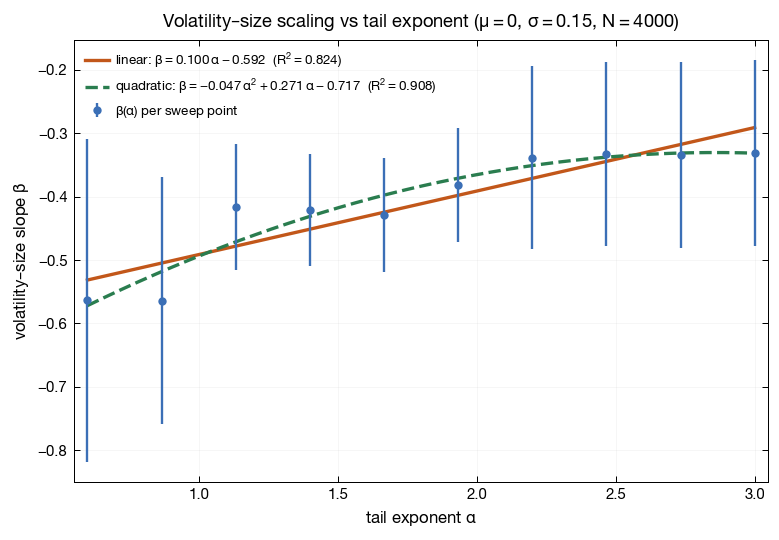

linear    fit:  beta = +0.1002 * alpha -0.5917                  (R^2 = 0.8243)
quadratic fit:  beta = -0.0473 * alpha^2 +0.2706 * alpha -0.7173   (R^2 = 0.9079)


In [5]:
good = np.isfinite(betas)
ag, bg, sg = alpha_grid[good], betas[good], beta_sems[good]

lin = np.polyfit(ag, bg, 1)
quad = np.polyfit(ag, bg, 2)
xx = np.linspace(ag.min(), ag.max(), 200)


def r2(y, y_hat):
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan


r2_lin = r2(bg, np.polyval(lin, ag))
r2_quad = r2(bg, np.polyval(quad, ag))

fig, ax = plt.subplots(figsize=(6.6, 4.6))
ax.errorbar(ag, bg, yerr=sg, fmt="o", color="#3b6fb6", ms=5, capsize=3, zorder=3,
            label=r"$\beta(\alpha)$ per sweep point")
ax.plot(xx, np.polyval(lin, xx), color=ACCENT, lw=2,
        label=rf"linear: $\beta = {lin[0]:.3f}\,\alpha {lin[1]:+.3f}$  ($R^2={r2_lin:.3f}$)")
ax.plot(xx, np.polyval(quad, xx), "--", color="#2a7d4f", lw=2,
        label=(rf"quadratic: $\beta = {quad[0]:.3f}\,\alpha^2 {quad[1]:+.3f}\,\alpha "
               rf"{quad[2]:+.3f}$  ($R^2={r2_quad:.3f}$)"))
ax.set(xlabel=r"tail exponent $\alpha$", ylabel=r"volatility–size slope $\beta$",
       title=rf"Volatility–size scaling vs tail exponent ($\mu=0$, $\sigma={sigma}$, $N={N}$)")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"linear    fit:  beta = {lin[0]:+.4f} * alpha {lin[1]:+.4f}"
      f"                  (R^2 = {r2_lin:.4f})")
print(f"quadratic fit:  beta = {quad[0]:+.4f} * alpha^2 {quad[1]:+.4f} * alpha {quad[2]:+.4f}"
      f"   (R^2 = {r2_quad:.4f})")